# **Customer Satisfaction Scores using Deep Learning**



**Problem Overview**

This project focuses on predicting Customer Satisfaction (CSAT) scores using Deep Learning Artificial Neural Networks (ANN). In the context of e-commerce, understanding customer satisfaction through their interactions and feedback is crucial for enhancing service quality, customer retention, and overall business growth.


**Objective:**

 The goal of project is to leverage advanced neural network models, to forecast CSAT scores based on a myriad of interaction-related features, providing actionable insights for service improvement.

In [37]:
##impoerting required libraries for the seeing the data and its trends
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ft
import warnings
warnings.filterwarnings('ignore')

In [38]:
df = pd.read_csv('/content/eCommerce_Customer_support_data.csv')
df

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85902,505ea5e7-c475-4fac-ac36-1d19a4cb610f,Inbound,Refund Related,Refund Enquiry,NaN,1b5a2b9c-a95f-405f-a42e-5b1b693f3dc9,NaN,30/08/2023 23:20,31/08/2023 07:22,31-Aug-23,NaN,NaN,NaN,NaN,Brandon Leon,Ethan Tan,William Kim,On Job Training,Morning,4
85903,44b38d3f-1523-4182-aba2-72917586647c,Inbound,Order Related,Seller Cancelled Order,Supported team customer executive good,d0e8a817-96d5-4ace-bb82-adec50398e22,NaN,31/08/2023 08:15,31/08/2023 08:17,31-Aug-23,NaN,NaN,NaN,NaN,Linda Foster,Noah Patel,Emily Chen,>90,Morning,5
85904,723bce2c-496c-4aa8-a64b-ca17004528f0,Inbound,Order Related,Order status enquiry,need to improve with proper details.,bdefe788-ccec-4eda-8ca4-51045e68db8a,NaN,31/08/2023 18:57,31/08/2023 19:02,31-Aug-23,NaN,NaN,NaN,NaN,Kimberly Martinez,Aiden Patel,Olivia Tan,On Job Training,Evening,5
85905,707528ee-6873-4192-bfa9-a491f1c08ab5,Inbound,Feedback,UnProfessional Behaviour,NaN,a031ec28-0c5e-450e-95b2-592342c40bc4,NaN,31/08/2023 19:59,31/08/2023 20:00,31-Aug-23,NaN,NaN,NaN,NaN,Daniel Martin,Olivia Suzuki,Olivia Tan,>90,Morning,4


In [39]:
#to check the number of rows and columns in the dataset
df.shape

(85907, 20)

In [40]:
#Variables in the dataset
print(f'Variables in the dataset : {list(df.columns)}')

Variables in the dataset : ['Unique id', 'channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Customer_City', 'Product_category', 'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score']


In [41]:
##this function allows us to define the required summary attributes from the dataset we required
def summary(df):
    summry = pd.DataFrame(df.dtypes, columns=['Data type'])
    summry['#Missing'] = df.isnull().sum().values
    summry['#Duplicate'] = df.duplicated().sum()
    summry['#Unique'] = df.nunique().values
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summry['Min'] = desc['min'].values
    summry['Max'] = desc['max'].values
    summry['Avg'] = desc['mean'].values
    summry['Std dev'] = desc['std'].values
    summry['Top value'] = desc['top'].values
    summry['Freq'] = desc['freq'].values

    return summry

In [42]:
summary(df).style.set_caption("<b style='font-size:16px;'>DATA SUMMARY</b>").\
background_gradient(cmap='Blues', axis=0). \
set_properties(**{'border': '1.3px dotted', 'color': '', 'caption-side': 'left'})

,Data type,#Missing,#Duplicate,#Unique,Min,Max,Avg,Std dev,Top value,Freq
Unique id,object,0,0,85907,nan,nan,nan,nan,07c7a878-0d5a-42e0-97ef-de59abec0238,1
channel_name,object,0,0,3,nan,nan,nan,nan,Inbound,68142
category,object,0,0,12,nan,nan,nan,nan,Returns,44097
Sub-category,object,0,0,57,nan,nan,nan,nan,Reverse Pickup Enquiry,22389
Customer Remarks,object,57165,0,18231,nan,nan,nan,nan,Good,1390
Order_id,object,18232,0,67675,nan,nan,nan,nan,3230db30-f8da-4c44-8636-ec76d1d3d4f3,1
order_date_time,object,68693,0,13766,nan,nan,nan,nan,09/08/2023 11:55,7
Issue_reported at,object,0,0,30923,nan,nan,nan,nan,13/08/2023 10:40,13
issue_responded,object,0,0,30262,nan,nan,nan,nan,28/08/2023 00:00,3378
Survey_response_Date,object,0,0,31,nan,nan,nan,nan,28-Aug-23,3452


In [46]:
# finding null values and unique value counts
null_values= round(df.isnull().sum() * 100 / len(df),2)
unique_values=df.nunique()
analysis_df = pd.DataFrame({'column_name': df.columns,"unique_values": unique_values,'null_values_%': null_values,"data_type":df.dtypes})
analysis_df.reset_index(drop=True,inplace=True)
analysis_df


,column_name,unique_values,null_values_%,data_type
0,Unique id,85907,0.00,object
1,channel_name,3,0.00,object
2,category,12,0.00,object
3,Sub-category,57,0.00,object
4,Customer Remarks,18231,66.54,object
5,Order_id,67675,21.22,object
6,order_date_time,13766,79.96,object
7,Issue_reported at,30923,0.00,object
8,issue_responded,30262,0.00,object
9,Survey_response_Date,31,0.00,object


In [49]:
# This function helps us to check and drop rows with missing values
def check_drop_missing_values(df):
  missing_count = df.isnull().sum().sum()
  if missing_count > 0:
    print(f'Total missing values: {missing_count}')
    print('Dropping rows with missing values...')
    df = df.dropna()
  else:
    print('No missing values found.')
  return df


In [53]:
# Dropping identification number as they are not important for our project
df = df.drop(columns = ['Unique id','Order_id'])

In [55]:
df.head(2)

,channel_name,category,Sub-category,Customer Remarks,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,Outcall,Product Queries,Life Insurance,NaN,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,Outcall,Product Queries,Product Specific Information,NaN,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5


In [57]:
# Converting datetime columns to same format for easy understanding and helpful during the process
df['order_date_time'] = pd.to_datetime(df['order_date_time'])
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], format='mixed', dayfirst=True)
df['issue_responded'] = pd.to_datetime(df['issue_responded'], format='mixed', dayfirst=True)
df['Survey_response_Date'] = pd.to_datetime(df['Survey_response_Date'])

,CSAT Score,Count
0,1,11230
1,2,1283
2,3,2558
3,4,11219
4,5,59617


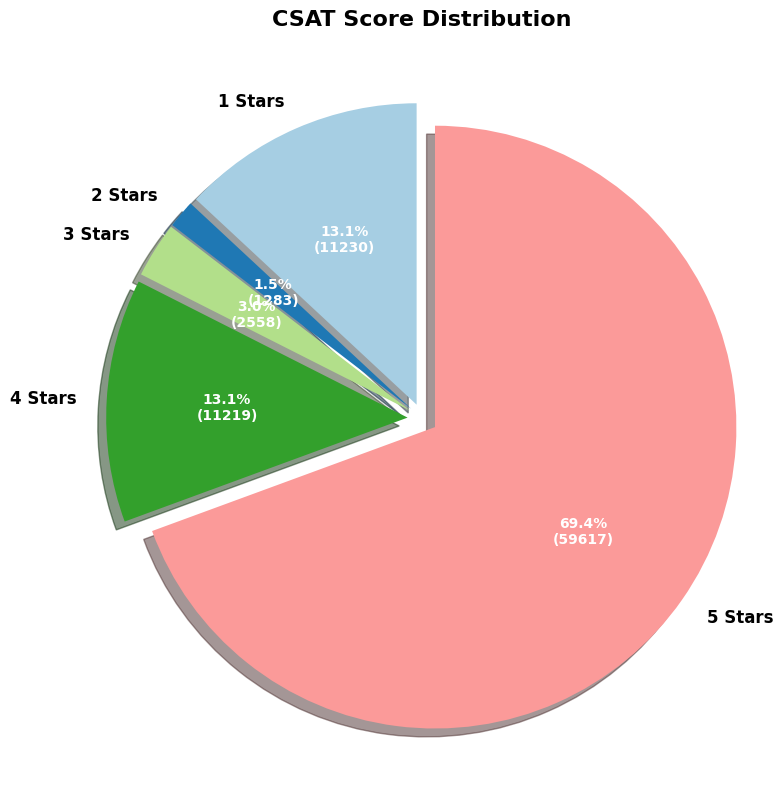

In [59]:

# Calculate CSAT score counts
csat_counts = df['CSAT Score'].value_counts().sort_index()
labels = [f'{int(score)} Stars' for score in csat_counts.index]
sizes = csat_counts.values
colors = plt.cm.Paired.colors[:len(sizes)]
explode = [0.05] * len(sizes)  # Slightly explode all slices

# Display value counts
display(pd.DataFrame({'CSAT Score': csat_counts.index, 'Count': csat_counts.values}))

# Plotting
plt.figure(figsize=(8, 8))
patches, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct/100.*sum(sizes)))})',
    startangle=90,
    colors=colors,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 12}
)

# Styling
for text in texts:
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title('CSAT Score Distribution', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')  # Ensures pie chart is a circle
plt.tight_layout()
plt.show()


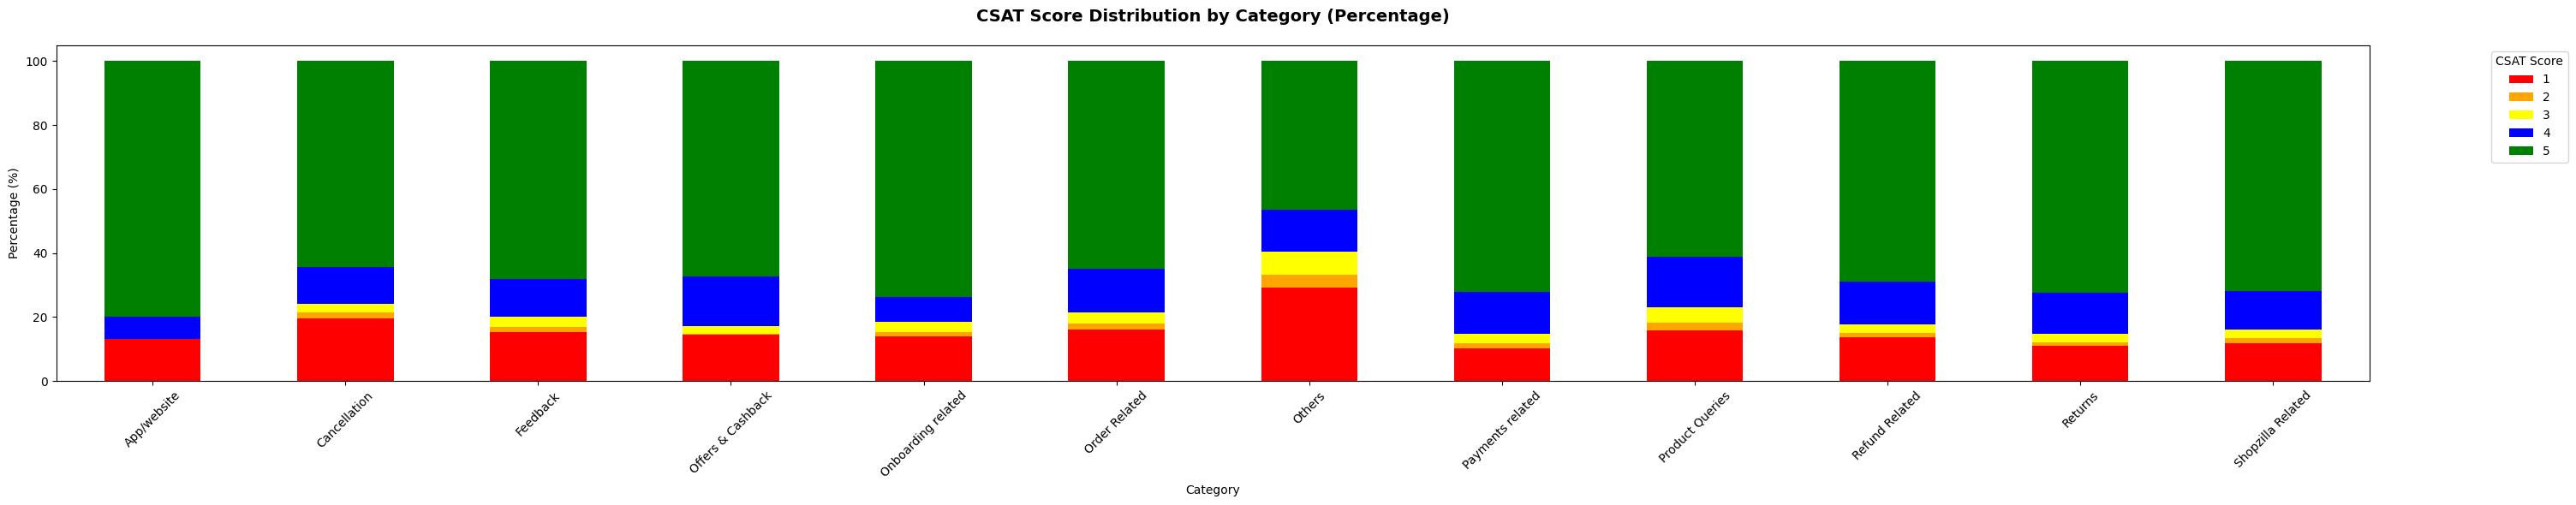

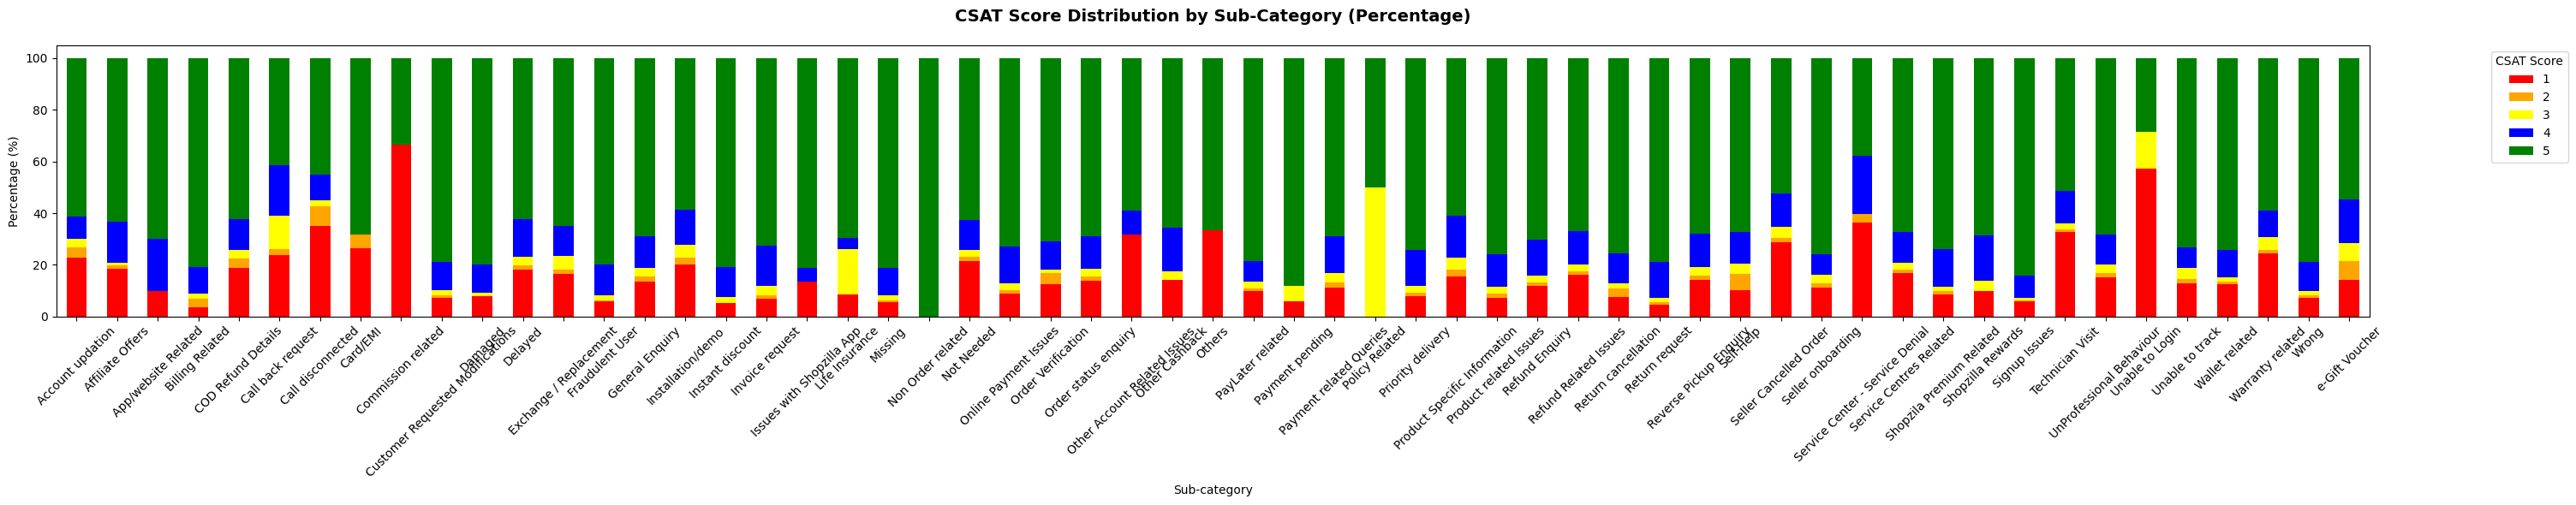

In [63]:
# Calculate percentage of each CSAT score within each category
category_csat_counts = df.groupby(['category', 'CSAT Score']).size().unstack(fill_value=0)
category_csat_percentages = category_csat_counts.div(category_csat_counts.sum(axis=1), axis=0) * 100

# Plot stacked bar chart with percentages
custom_colors = {1: 'red', 5: 'green', 2: 'orange', 3: 'yellow', 4: 'blue'}
# Plot stacked bar chart with custom colors
category_csat_percentages.plot(kind='bar', stacked=True, figsize=(30, 6), color=[custom_colors[col] for col in category_csat_percentages.columns])
# Customize plot labels and legend
plt.title('CSAT Score Distribution by Category (Percentage)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Category')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='CSAT Score', bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

# Calculate percentage of each CSAT score within each category
category_csat_counts = df.groupby(['Sub-category', 'CSAT Score']).size().unstack(fill_value=0)
category_csat_percentages = category_csat_counts.div(category_csat_counts.sum(axis=1), axis=0) * 100

# Plot stacked bar chart with custom colors
category_csat_percentages.plot(kind='bar', stacked=True, figsize=(30, 6), color=[custom_colors[col] for col in category_csat_percentages.columns])
# Customize plot labels and legend
plt.title('CSAT Score Distribution by Sub-Category (Percentage)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Sub-category')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='CSAT Score', bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

In [64]:
# Highlight categories where CSAT score 5 > 80%
categories_high_csat1 = category_csat_percentages[category_csat_percentages[5] > 80].index

# Print categories where CSAT score 5 exceeds 80% along with percentages
print(f"Categories where CSAT score 5 exceeds 80%:")
for category in categories_high_csat1:
    percentage = category_csat_percentages.loc[category, 5]
    print(f"- {category}: {percentage:.2f}%")

Categories where CSAT score 5 exceeds 80%:
- Billing Related: 80.70%
- Instant discount: 80.77%
- Issues with Shopzilla App: 81.08%
- Missing: 81.26%
- Non Order related: 100.00%
- Payment pending: 88.24%
- Signup Issues: 84.05%


In [65]:
# Highlight categories where CSAT score 1 > 20%
categories_high_csat1 = category_csat_percentages[category_csat_percentages[1] > 20].index

# Print categories where CSAT score 1 exceeds 20% along with percentages
print(f"Categories where CSAT score 1 exceeds 20%:")
for category in categories_high_csat1:
    percentage = category_csat_percentages.loc[category, 1]
    print(f"- {category}: {percentage:.2f}%")


Categories where CSAT score 1 exceeds 20%:
- Account updation: 22.67%
- Call back request: 23.91%
- Call disconnected: 35.00%
- Card/EMI: 26.32%
- Commission related: 66.67%
- Not Needed: 21.51%
- Other Account Related Issues: 31.82%
- Others: 33.33%
- Seller Cancelled Order: 28.80%
- Service Center - Service Denial: 36.21%
- Technician Visit: 32.80%
- Unable to Login: 57.14%
- Warranty related: 24.36%


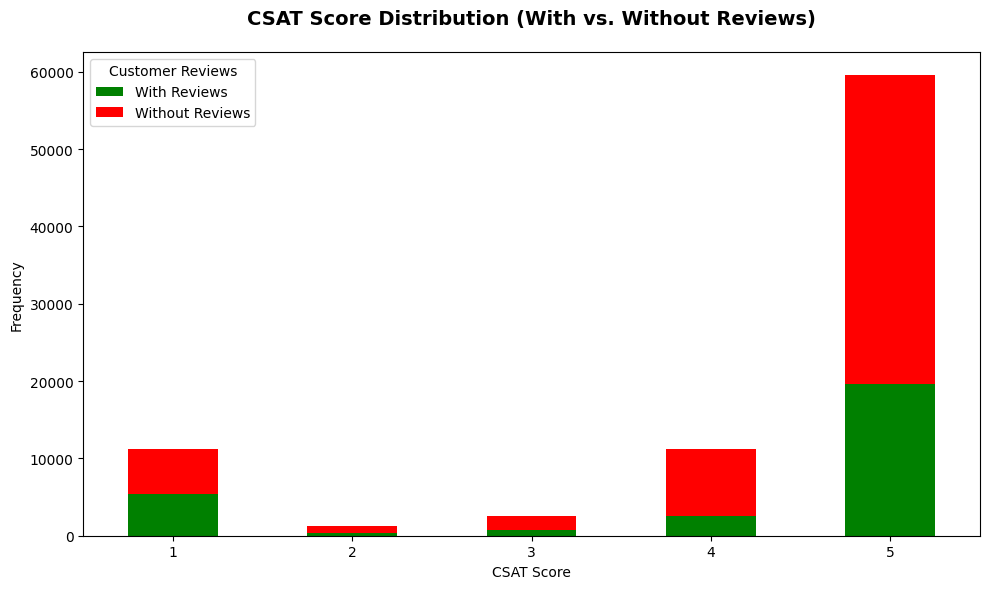

In [70]:
# Check for missing or empty customer reviews
missing_reviews = df['Customer Remarks'].isna() | (df['Customer Remarks'].str.strip() == '')

# CSAT score distribution by presence of customer reviews
csat_with_reviews = df[~missing_reviews]['CSAT Score'].value_counts().sort_index()
csat_without_reviews = df[missing_reviews]['CSAT Score'].value_counts().sort_index()

# Combine the data into a single DataFrame for stacked plotting
csat_combined = pd.DataFrame({
    'With Reviews': csat_with_reviews,
    'Without Reviews': csat_without_reviews
}).fillna(0)

# Plotting the stacked bar chart
csat_combined.plot(kind='bar', stacked=True, color=['green', 'red'], figsize=(10, 6))

# Customize plot labels and title
plt.title('CSAT Score Distribution (With vs. Without Reviews)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('CSAT Score')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.legend(title='Customer Reviews')

# Display the plot
plt.tight_layout()
plt.show()

In [72]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [76]:
# Initialize VADER
sid = SentimentIntensityAnalyzer()

# Function to calculate sentiment score
def calculate_sentiment(remark):
    scores = sid.polarity_scores(remark)
    compound_score = scores['compound']
    return compound_score

# Imputing mode in customer_remarks and with supporting insight from chart-3
df['Customer Remarks'] = df['Customer Remarks'].fillna('good')
# Apply sentiment calculation
df['sentiment'] = df['Customer Remarks'].apply(calculate_sentiment)

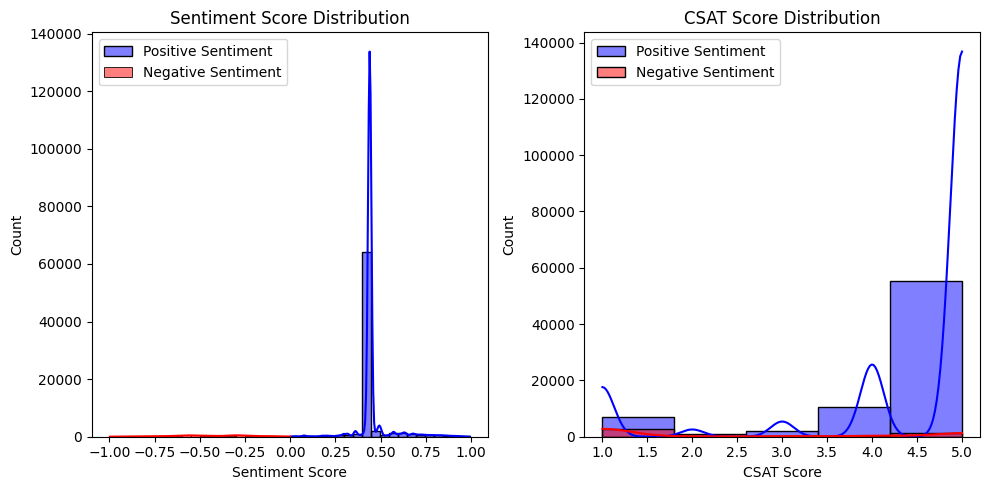

In [79]:
# Set up figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

# Plot 1: Sentiment Score Distribution
sns.histplot(df[df['sentiment'] > 0]['sentiment'], bins=20, kde=True, color='blue', ax=axes[0], label='Positive Sentiment')
sns.histplot(df[df['sentiment'] < 0]['sentiment'], bins=20, kde=True, color='red', ax=axes[0], label='Negative Sentiment')
axes[0].set_title('Sentiment Score Distribution')
axes[0].set_xlabel('Sentiment Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2: Sentiment Score with CSAT Distribution
# Positive sentiment scores
sns.histplot(df[df['sentiment'] > 0]['CSAT Score'], bins=5, kde=True, color='blue', alpha=0.5, ax=axes[1], label='Positive Sentiment')
# Negative sentiment scores
sns.histplot(df[df['sentiment'] < 0]['CSAT Score'], bins=5, kde=True, color='red', alpha=0.5, ax=axes[1], label='Negative Sentiment')
axes[1].set_title('CSAT Score Distribution')
axes[1].set_xlabel('CSAT Score')
axes[1].set_ylabel('Count')
axes[1].legend()

# Adjust layout and display
plt.tight_layout()
plt.show()

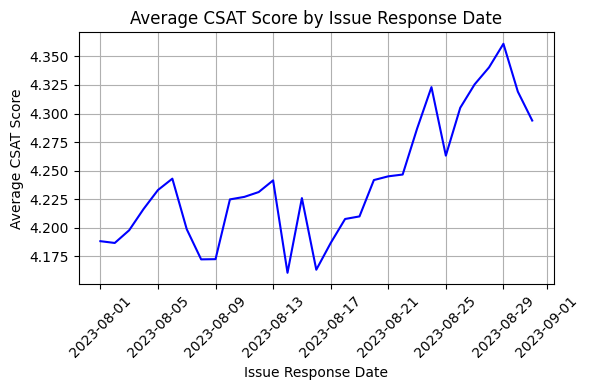

In [80]:
# Aggregate CSAT scores by issue_responded date
csat_by_date = df.groupby(df['issue_responded'].dt.date)['CSAT Score'].mean()

# Plotting the line chart
plt.figure(figsize=(6, 4))
plt.plot(csat_by_date.index, csat_by_date.values, linestyle='-', color='blue')

plt.title('Average CSAT Score by Issue Response Date')
plt.xlabel('Issue Response Date')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

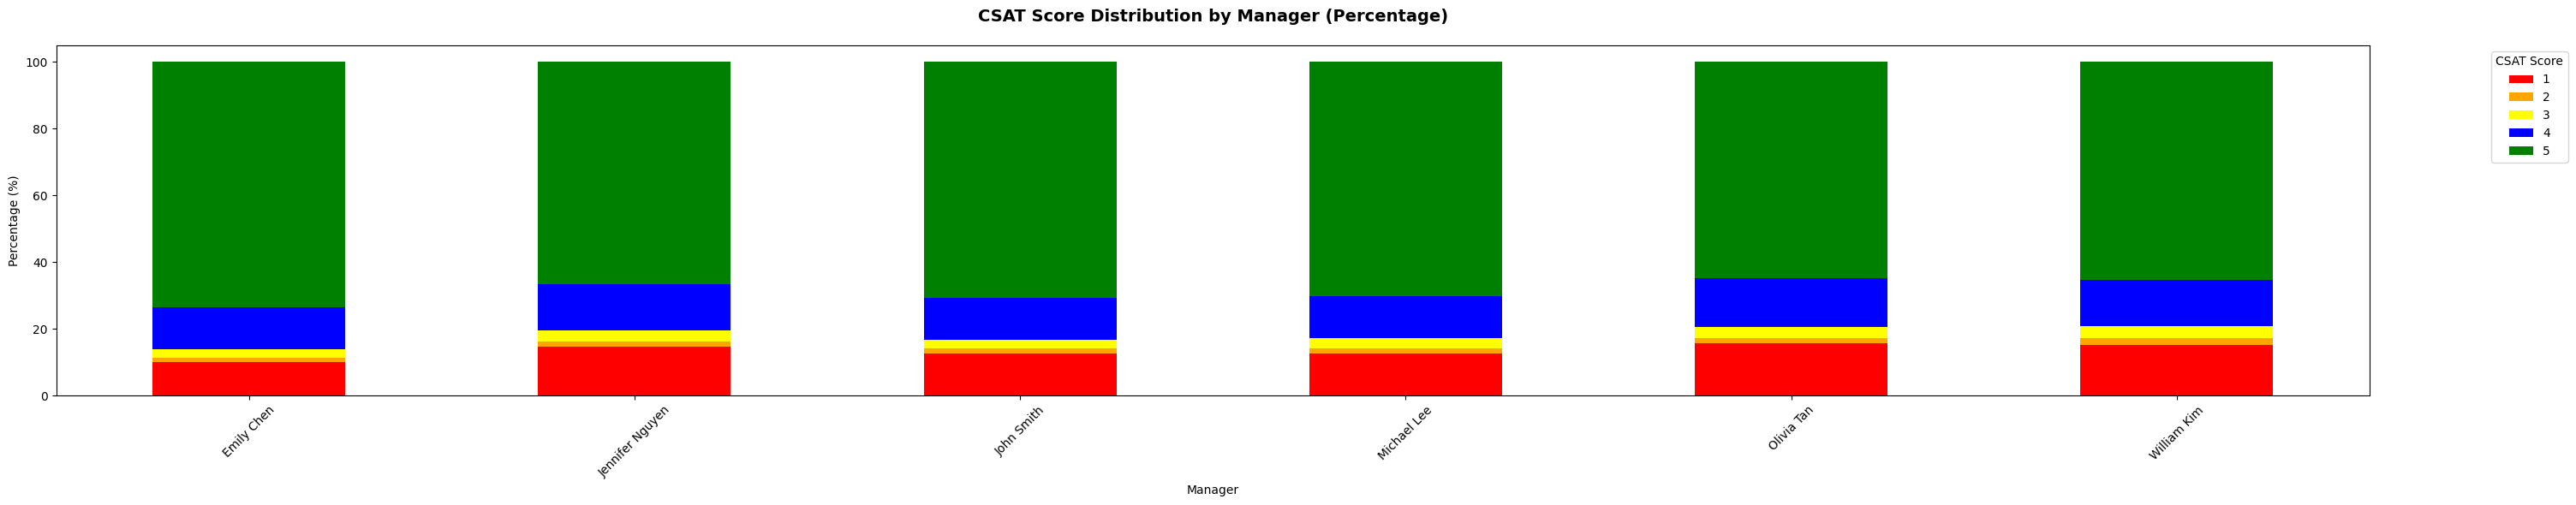

In [81]:
# Calculate percentage of each CSAT score within each category
manager_csat_counts = df.groupby(['Manager', 'CSAT Score']).size().unstack(fill_value=0)
manager_csat_percentages = manager_csat_counts.div(manager_csat_counts.sum(axis=1), axis=0) * 100

# Plot stacked bar chart with percentages
custom_colors = {1: 'red', 5: 'green', 2: 'orange', 3: 'yellow', 4: 'blue'}
# Plot stacked bar chart with custom colors
manager_csat_percentages.plot(kind='bar', stacked=True, figsize=(30, 6), color=[custom_colors[col] for col in manager_csat_percentages.columns])
# Customize plot labels and legend
plt.title('CSAT Score Distribution by Manager (Percentage)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Manager')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='CSAT Score', bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

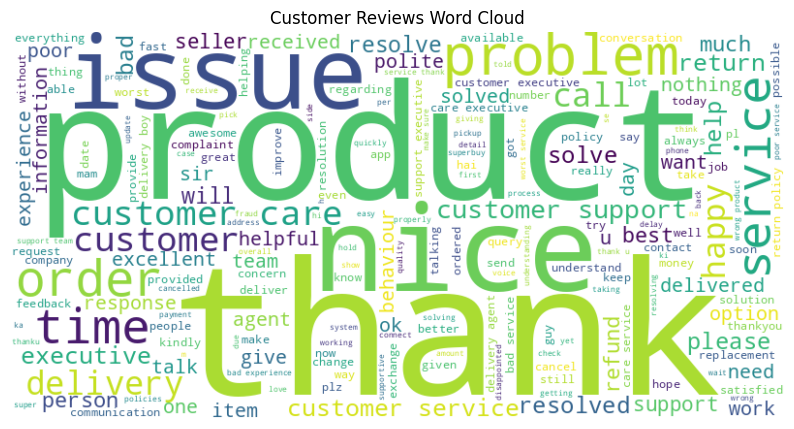

In [82]:
# Combine all customer remarks into a single text string
text = ' '.join(df['Customer Remarks'].dropna())

# Remove the word "good" (case insensitive)
text = text.lower().replace('good', '')
text = text.lower().replace('shopzilla', '')


# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Plot the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Customer Reviews Word Cloud')
plt.axis('off')
plt.show()

In [84]:
# Calculate the average CSAT score for each agent
agent_performance = df.groupby('Agent_name')['CSAT Score'].mean().reset_index()

# Sort the agents by average CSAT score to find top and least performers
top_performers = agent_performance.sort_values(by='CSAT Score', ascending=False).head()
least_performers = agent_performance.sort_values(by='CSAT Score', ascending=True).head()

# Display the top performers
print("Top Performers:")
print(top_performers.to_string(index=False))

# Display the least performers
print("\nLeast Performers:")
print(least_performers.to_string(index=False))

Top Performers:
     Agent_name  CSAT Score
Pamela Robinson    4.956522
  Virginia Lane    4.909910
       Sean Gay    4.909091
  Taylor Nelson    4.888889
    Nancy Singh    4.868421

Least Performers:
        Agent_name  CSAT Score
     Philip Harmon    1.809524
    Rebecca Miller    1.954545
   Curtis Mccarthy    2.100000
Virginia Mccormick    2.114286
     Nicole Zavala    2.133333


In [85]:
df

,channel_name,category,Sub-category,Customer Remarks,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,sentiment
0,Outcall,Product Queries,Life Insurance,good,NaT,2023-08-01 11:13:00,2023-08-01 11:47:00,2023-08-01,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,0.4404
1,Outcall,Product Queries,Product Specific Information,good,NaT,2023-08-01 12:52:00,2023-08-01 12:54:00,2023-08-01,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,0.4404
2,Inbound,Order Related,Installation/demo,good,NaT,2023-08-01 20:16:00,2023-08-01 20:38:00,2023-08-01,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,0.4404
3,Inbound,Returns,Reverse Pickup Enquiry,good,NaT,2023-08-01 20:56:00,2023-08-01 21:16:00,2023-08-01,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,0.4404
4,Inbound,Cancellation,Not Needed,good,NaT,2023-08-01 10:30:00,2023-08-01 10:32:00,2023-08-01,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,0.4404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85902,Inbound,Refund Related,Refund Enquiry,good,NaT,2023-08-30 23:20:00,2023-08-31 07:22:00,2023-08-31,NaN,NaN,NaN,NaN,Brandon Leon,Ethan Tan,William Kim,On Job Training,Morning,4,0.4404
85903,Inbound,Order Related,Seller Cancelled Order,Supported team customer executive good,NaT,2023-08-31 08:15:00,2023-08-31 08:17:00,2023-08-31,NaN,NaN,NaN,NaN,Linda Foster,Noah Patel,Emily Chen,>90,Morning,5,0.6369
85904,Inbound,Order Related,Order status enquiry,need to improve with proper details.,NaT,2023-08-31 18:57:00,2023-08-31 19:02:00,2023-08-31,NaN,NaN,NaN,NaN,Kimberly Martinez,Aiden Patel,Olivia Tan,On Job Training,Evening,5,0.4404
85905,Inbound,Feedback,UnProfessional Behaviour,good,NaT,2023-08-31 19:59:00,2023-08-31 20:00:00,2023-08-31,NaN,NaN,NaN,NaN,Daniel Martin,Olivia Suzuki,Olivia Tan,>90,Morning,4,0.4404


In [86]:
# Calculate the median CSAT score for each agent
agent_performance = df.groupby('Agent_name')['CSAT Score'].median().reset_index()

# Check which agents have a median CSAT score less than 3
agents_below_3 = agent_performance[agent_performance['CSAT Score'] < 3]

# Display the agents with a median CSAT score less than 3
print("Agents with a median CSAT score less than 3:")
print(agents_below_3.to_string(index=False))

Agents with a median CSAT score less than 3:
        Agent_name  CSAT Score
      Alyssa Jones         2.0
       Amanda Cook         2.0
       Amber Brown         2.5
   Charles Morales         1.0
  Christine Castro         1.5
   Curtis Mccarthy         1.0
      Jason Wilson         1.5
     Joshua Oliver         2.5
     Melinda Mills         1.0
    Melissa Spence         1.0
     Nicole Zavala         1.0
      Pamela Perez         1.0
     Philip Harmon         1.0
    Rebecca Miller         1.0
      Sarah Keller         1.0
      Tommy Davies         1.0
 Veronica Anderson         1.0
Virginia Mccormick         1.0
      Wesley Meyer         1.0
     Willie Flores         1.0


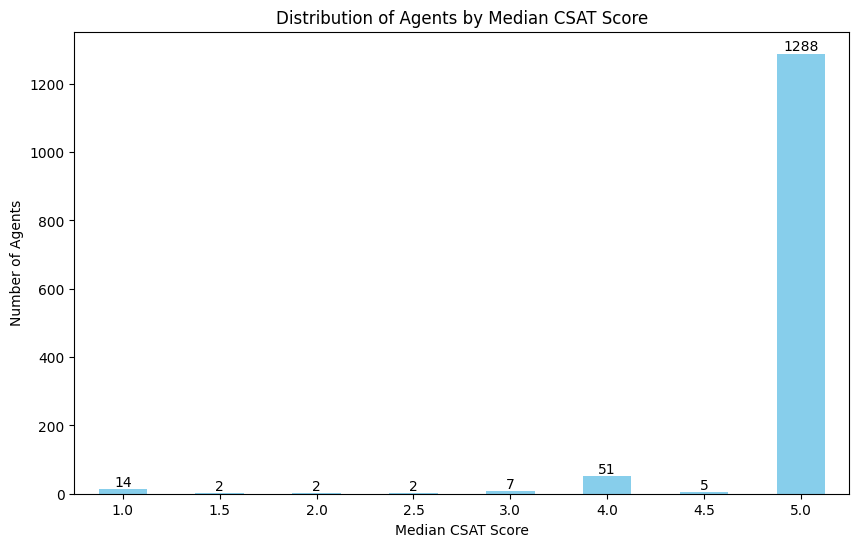

In [87]:
# Assuming 'df' is your DataFrame and 'agent_name' and 'csat_score' are the relevant columns
agent_median_scores = df.groupby('Agent_name')['CSAT Score'].median()

# Count the occurrences of each median score
median_score_counts = agent_median_scores.value_counts().sort_index()

# Plot the bar chart
plt.figure(figsize=(10, 6))
bars = median_score_counts.plot(kind='bar', color='skyblue')

# Customize the plot
plt.title('Distribution of Agents by Median CSAT Score')
plt.xlabel('Median CSAT Score')
plt.ylabel('Number of Agents')
plt.xticks(rotation=0)  # Rotate x-ticks for better readability

# Add counts above the bars
for index, value in enumerate(median_score_counts):
    plt.text(index, value + 0.1, str(value), ha='center', va='bottom')

plt.show()

In [90]:
#Dropping not needed variables
df1=df.drop(["Customer Remarks","order_date_time"],axis=1)
df1.sample(n=2)

,channel_name,category,Sub-category,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,sentiment
66263,Inbound,Payments related,Online Payment Issues,2023-08-25 13:37:00,2023-08-25 13:39:00,2023-08-25,NaN,NaN,NaN,NaN,James Cunningham,Emma Park,Jennifer Nguyen,On Job Training,Evening,5,0.4404
7692,Inbound,Returns,Technician Visit,2023-08-04 17:01:00,2023-08-04 17:20:00,2023-08-04,NaN,NaN,NaN,NaN,Patricia Duarte,Elijah Yamaguchi,Emily Chen,61-90,Evening,5,0.6124


In [91]:
#Replacing object dtype to timestamp dtype
col=['Issue_reported at','issue_responded','Survey_response_Date']
for i in col:
    df1[i]=pd.to_datetime(df1[i],dayfirst=True)
    print(i,": dtype =",df1[i].dtype)

Issue_reported at : dtype = datetime64[ns]
issue_responded : dtype = datetime64[ns]
Survey_response_Date : dtype = datetime64[ns]


In [92]:
#Replacing null value according to needs
for i in df1.columns:
    if (df1[i].isnull().sum()>0 and df1[i].dtype=="object"):
        df1[i].fillna("Unknown",inplace=True)
        print(i, "Variable has object dtype, so it got Replace its null values to Unknown \n")
    elif (df1[i].isnull().sum()>0 and df1[i].dtype=="float64"):
        df1[i].fillna(df1[i].median(),inplace=True)
        print(i, "Variable has float dtype, so it got Replace its null values to columns median value \n")

Customer_City Variable has object dtype, so it got Replace its null values to Unknown 

Product_category Variable has object dtype, so it got Replace its null values to Unknown 

Item_price Variable has float dtype, so it got Replace its null values to columns median value 

connected_handling_time Variable has float dtype, so it got Replace its null values to columns median value 



In [93]:
df1=df1[["channel_name","Tenure Bucket","Item_price","CSAT Score"]]

In [94]:
df1_=pd.get_dummies(df1,columns=["channel_name","Tenure Bucket"],drop_first=True)

In [95]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(df1_[["Item_price"]])

# transform train and test sets
df1_numerical_scaled = scaler.transform(df1_[["Item_price"]])
df1_numerical_scaled=pd.DataFrame(df1_numerical_scaled,columns=["Item_price"])

In [96]:
df1_main=pd.concat([df1_,df1_numerical_scaled],axis=1).iloc[:,1:]
df1_main

,CSAT Score,channel_name_Inbound,channel_name_Outcall,Tenure Bucket_31-60,Tenure Bucket_61-90,Tenure Bucket_>90,Tenure Bucket_On Job Training,Item_price
0,5,False,True,False,False,False,True,-0.155302
1,5,False,True,False,False,True,False,-0.155302
2,5,True,False,False,False,False,True,-0.155302
3,5,True,False,False,False,True,False,-0.155302
4,5,True,False,False,False,False,False,-0.155302
...,...,...,...,...,...,...,...,...
85902,4,True,False,False,False,False,True,-0.155302
85903,5,True,False,False,False,True,False,-0.155302
85904,5,True,False,False,False,False,True,-0.155302
85905,4,True,False,False,False,True,False,-0.155302


In [97]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [98]:
X = df1_main.drop(columns=['CSAT Score'])
y = df1_main['CSAT Score'].values

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [114]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from keras.optimizers import Adam

# Create the model
model = Sequential()

# First Dense layer with input dimension
model.add(Dense(128, input_dim=7))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.01))
model.add(Dropout(0.3))

# Second Dense layer
model.add(Dense(64))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.01))
model.add(Dropout(0.3))

# Third Dense layer
model.add(Dense(32))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.01))
model.add(Dropout(0.3))

# Output layer
model.add(Dense(6, activation='softmax'))

# Compile the model
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,454 (48.65 KB)

 Trainable params: 12,006 (46.90 KB)

 Non-trainable params: 448 (1.75 KB)

In [115]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adagrad',metrics=['accuracy'])

In [116]:
#an epoch is the number of times a training dataset passes through an algorithm
history = model.fit(X_train,y_train,epochs=50,validation_split=0.2)

Epoch 1/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.1767 - loss: 2.2698 - val_accuracy: 0.5910 - val_loss: 1.5365
Epoch 2/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4439 - loss: 1.5902 - val_accuracy: 0.6811 - val_loss: 1.3336
Epoch 3/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5559 - loss: 1.3906 - val_accuracy: 0.6871 - val_loss: 1.2342
Epoch 4/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6028 - loss: 1.3016 - val_accuracy: 0.6878 - val_loss: 1.1722
Epoch 5/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6237 - loss: 1.2568 - val_accuracy: 0.6882 - val_loss: 1.1290
Epoch 6/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6454 - loss: 1.2080 - val_accuracy: 0.6886 - val_loss: 1.0994
Epoch 7/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6524 - loss: 1.1808 - val_accuracy: 0.6885 - val_loss: 1.0791
Epoch 8/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6548 - loss: 1.178

In [117]:
y_prob = model.predict(X_test)

537/537 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [118]:
y_pred = y_prob.argmax(axis=1)

In [119]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6907810499359796

In [120]:
!pip3 install gradio

In [121]:
# Define the prediction function
import gradio as gr
def predict(feature1, feature2, feature3, feature4, feature5, feature6, feature7):
    # Convert "True"/"False" to 1/0
    features_np = [
        1 if feature1 == "True" else 0,
        1 if feature2 == "True" else 0,
        1 if feature3 == "True" else 0,
        1 if feature4 == "True" else 0,
        1 if feature5 == "True" else 0,
        1 if feature6 == "True" else 0,

        #float(feature7)  # Convert text input to float
    ]
    feature7 = np.array([[feature7]])
    feature7= scaler.transform(feature7)[0, 0]

    features_np = features_np + [feature7]
    features_np = np.array(features_np).reshape(1, -1)

    # Make prediction
    prediction = model.predict(features_np)
    predicted_class = np.argmax(prediction, axis=1)
    return str(predicted_class[0])  # Convert to string for display

# Create the Gradio interface
interface = gr.Interface(
    fn=predict,  # The function to call for prediction
    inputs=[
        gr.Radio(choices=["True", "False"], label="channel_name_Inbound"),
        gr.Radio(choices=["True", "False"], label="channel_name_Outcall"),
        gr.Radio(choices=["True", "False"], label="Tenure Bucket_31-60"),
        gr.Radio(choices=["True", "False"], label="Tenure Bucket_61-90"),
        gr.Radio(choices=["True", "False"], label="Tenure Bucket_>90"),
        gr.Radio(choices=["True", "False"], label="Tenure Bucket_On Job Training"),
        gr.Textbox(label="Item_price", type="text")  # Textbox for numerical input
    ],
    outputs=gr.Textbox(label="CSAT Score"),
    title="eCommerce Customer Service Satisfaction App",
    description="Please enter all the values to predict CSAT Score"
)

# Launch the interface
interface.launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6bbe43d227153c3694.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
